# Task-1: Disparity maps in stereo images

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import maxflow
import math
import time



In [64]:

class Energy():

    def __init__(self, NbNodes, NbEdges):
        self.graph = maxflow.Graph[int](NbNodes, NbEdges)
        self.Econst = 0

    def add_term1(self, node_id, weight_s, weight_t):
        self.graph.add_tedge(node_id, weight_t, weight_s)
        return

    def add_variable(self, weight_s, weight_t):
        node_id = self.graph.add_nodes(1)[0]
        self.add_term1(node_id, weight_s, weight_t)
        return node_id

    def add_constant(self, cst):
        self.Econst += cst
        return

    def add_term2(self, node_x, node_y, E00, E01, E10, E11):
        self.graph.add_tedge(node_x, E11, E01)
        self.graph.add_tedge(node_y, 0, E00 - E01)
        self.graph.add_edge(node_x, node_y, 0, E01 + E10 - E00 - E11)
        return

    def forbid01(self, node_x, node_y):
        self.graph.add_edge(node_x, node_y, 2**31 - 1, 0)
        return

    def minimize(self):
        return self.Econst + self.graph.maxflow()

    def get_var(self, node_x):
        return self.graph.get_segment(node_x)
    

def sub_pixel(Img, shape):
   
    imMin = np.zeros(shape)
    imMax = np.zeros(shape)

    for y in range(shape[0]):
        for x in range(shape[1]):
            I = int(Img[y, x])
            I1,I2,I3,I4 = I,I,I,I
            if x>0:
                I1 = (int(Img[y, x - 1]) + I) / 2
            else:
                I1 = I
            if x+1<shape[1]:
                I2 = (int(Img[y, x + 1]) + I) / 2
            else:
                I2 = I
            if y>0:
                I3 = (int(Img[y - 1, x]) + I) / 2
            else:
                I3 = I
            if y+1<shape[0]:
                I4 = (int(Img[y + 1, x]) + I) / 2
            else:
                I4 = I
            IMin=I
            IMin=min(min(I1,I2),min(I3,min(I4,IMin)))
            IMax=I
            IMax=max(max(I1,I2),max(I3,max(I4,IMax)))

            imMin[y, x] = IMin
            imMax[y, x] = IMax

    return imMin, imMax



In [65]:

ALPHA_VAL = -1
ABSENT_VAL = -2
NEIGHBORS = [(0, -1), (1, 0)]
CUTOFF = 30
MAX_DENOM = 16


def set_fractions(params, K, lambda1, lambda2):
    minError = 2 ** 30
    for i in range(0, MAX_DENOM ):
        e = 0
        numK = 0
        num1 = 0
        num2 = 0
        if K > 0:
            numK = (i+1) * K + .5            
            numK = math.floor(numK)
            e += abs(numK / ((i+1) * K) - 1.0)

        if lambda1 > 0:
            num1 = (i+1) * lambda1 + .5
            num1 = math.floor(num1)
            e += abs(num1 / ((i+1) * lambda1) - 1.0)

        if lambda2 > 0:
            num2 = (i+1) * lambda2 + .5            
            num2 = math.floor(num2)
            e += abs(num2 / ((i+1) * lambda2) - 1.0)

        if e < minError:
            minError = e
            params.denominator = i+1
            params.K = numK
            params.lambda1 = num1
            params.lambda2 = num2
    return params


def cal_parameters(match, params, K, lambda_, lambda1, lambda2):
 
    if K < 0:
        match.set_parameters(params)
        K = match.calculate_K()
    if lambda_ <= 0:
        lambda_ = K / 5
    if lambda1 <= 0:
        lambda1 = 3 * lambda_
    if lambda2 <= 0:
        lambda2 = lambda_
    params = set_fractions(params, K, lambda1, lambda2)
    match.set_parameters(params)
    return match


def coord_add(coordP, coordQ):
    x,y=coordP
    w,h=coordQ
    x+=w
    y+=h
    return (x,y)


def inRect(coordP, coordR):
    x, y = coordP
    w, h = coordR
    if 0 <= x < w :
        if 0 <= y < h:
            return True
    return False
   

def dist_interval(v, mi, ma):
    if v<=ma and v>=mi:
        return 0
    elif v<mi:
        return mi-v
    return v-ma
  


class Parameters:
    def __init__(self, L2, denominator, edgeThresh, lambda1, lambda2, K, maxIter):
        self.L2 = L2
        self.denominator = denominator
        self.edgeThresh = edgeThresh
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.K = K
        self.maxIter = maxIter


class Match:

    def __init__(self, imgLeft, imgRight,data_penalty_func):
        height=imgLeft.shape[0] if imgLeft.shape[0]<imgRight.shape[0] else imgRight.shape[0]
        self.imSizeL = (height, imgLeft.shape[1])  # dimensions of left image
        self.imSizeR = (height, imgRight.shape[1])  # dimensions of right image
        self.posIter = np.ones(shape=self.imSizeL)
        
        self.imgL = imgLeft
        self.imgR = imgRight
        self.imgLMin = None
        self.imgLMax = None
        self.imgRMin = None
        self.imgRMax = None

        self.dispMin = self.dispMax = 0  
        self.currentEnergy = 0  
        self.params = None  
        self.disparityL = np.zeros(shape=self.imSizeL, dtype=np.int64)  # disparity map to be returned
        self.vars0 = np.zeros(shape=self.imSizeL, dtype=np.int64)  # variables before alpha expansion
        self.varsA = np.zeros(shape=self.imSizeL, dtype=np.int64)  # variables after alpha expansion
        self.OCCLUDED = 2 ** 31 - 1
        self.data_penalty_func=data_penalty_func

    def set_disparity_range(self, dMin, dMax):
        self.dispMin = dMin
        self.dispMax = dMax
        self.disparityL = np.ones_like(self.disparityL, dtype=np.int64) * self.OCCLUDED

    def set_parameters(self, params):
        self.params = params
        self.init_sub_pixel()
        return

    def calculate_K(self):
        dispsize = self.dispMax - self.dispMin + 1
        k = (dispsize + 2) // 4
        k=max(k,3)
        array = np.ones(k)
        sum_val = 0
        num = 0
        xmin=0
        if -self.dispMin>xmin:
            xmin=-self.dispMin
        xmax=self.imSizeL[1]
        t=self.imSizeR[1]-self.dispMax
        if xmax>t:
            xmax=t
        n=self.imSizeL[0]
        if n>self.imSizeR[0]:
            n=self.imSizeR[0]

        for y in range(0, n,1):
            for x in range(xmin, xmax,1):
                i = 0
                for d in range(self.dispMin, self.dispMax + 1):
                    delta =  self.data_penalty((y, x), (y, x + d))
                    if i>=k:
                        for j in range(k):
                            if delta>=array[j]:
                                continue
                            tmp=delta
                            delta=array[j]
                            array[j]=tmp
                    elif i<k:
                        array[i]=delta
                        i+=1
                sum_val = sum_val+ np.max(array)
                num += 1
        K=sum_val/num
        return K

    def init_sub_pixel(self):
        if self.data_penalty_func=="msd":
            return
        self.imgLMin = np.zeros(shape=self.imSizeL)
        self.imgLMax = np.zeros(shape=self.imSizeL)
        self.imgRMin = np.zeros(shape=self.imSizeR)
        self.imgRMax = np.zeros(shape=self.imSizeR)

        self.imgLMin, self.imgLMax =sub_pixel(self.imgL, self.imgLMin.shape)
        self.imgRMin, self.imgRMax =sub_pixel(self.imgR, self.imgRMin.shape)        
        return

    # Data penalty functions
    def data_msd(self, coordL, coordR):
        Ip = self.imgL[coordL]
        Iq = self.imgR[coordR]
        ans =(Ip - Iq) ** 2
        ans = np.mean(ans)
        return ans
    def data_penalty(self, coordL, coordR):

        if self.data_penalty_func=="msd":
            return self.data_msd(coordL, coordR)
        
        Ip = self.imgL[coordL]
        Iq = self.imgR[coordR]

        IpMin = self.imgLMin[coordL]
        IqMin = self.imgRMin[coordR]

        IpMax = self.imgLMax[coordL]
        IqMax = self.imgRMax[coordR]

        dp = dist_interval(Ip, IqMin, IqMax)
        dq = dist_interval(Iq, IpMin, IpMax)
        d = min(dp, dq)

        d=d**2 if self.params.L2 else d
        

        return d

    
    def data_occlusion_penalty(self, coordL, coordR):
     
        
        D = self.data_penalty(coordL, coordR)

        return self.params.denominator * D - self.params.K

    def smoothness_penalty(self, coordP1, coordP2, disp):
      
        
        dl = abs(self.imgL[coordP1] - self.imgL[coordP2])
        dr = abs(self.imgR[coordP1[0], coordP1[1] + disp] - self.imgR[coordP2[0], coordP2[1] + disp])
        if dl<self.params.edgeThresh and dr<self.params.edgeThresh:
            return self.params.lambda1
        return self.params.lambda2


    def expansion_move(self, alpha):
       
        e = Energy(2 * self.imSizeL[0] * self.imSizeL[1], 12 * self.imSizeL[0] * self.imSizeL[1])

        for index in np.ndindex(self.posIter.shape):
            self.build_nodes(e, index, alpha)


        for index in np.ndindex(self.posIter.shape):
            for i in range(len(NEIGHBORS)):
                coordP2 = coord_add(index, NEIGHBORS[i])
                if inRect(coordP2, self.imSizeL):
                    self.build_smoothness(e, index, coordP2, alpha)


        for index in np.ndindex(self.posIter.shape):
            self.build_uniqueness(e, index, alpha)

        
        min_energy=e.minimize()
        
        if min_energy<self.currentEnergy:
            self.currentEnergy=min_energy
            self.update_disparity(e, alpha)
            return True
        return False
    
    # Graph construction
    def build_nodes(self, energy, coordP, alpha):
       
        d = self.disparityL[coordP]
        coordQ = (coordP[0], coordP[1] + d)
        if alpha == d:
            self.vars0[coordP] = ALPHA_VAL
            self.varsA[coordP] = ALPHA_VAL
            energy.add_constant(self.data_occlusion_penalty(coordP, coordQ))
            return

        if d == self.OCCLUDED:
            self.vars0[coordP] = ABSENT_VAL
        else:
            self.vars0[coordP] = energy.add_variable(self.data_occlusion_penalty(coordP, coordQ), 0)

        coordQ = (coordP[0], coordP[1] + alpha)
        if inRect(coordQ, self.imSizeR)==False:
            self.varsA[coordP] = ABSENT_VAL
        else:
            self.varsA[coordP] = energy.add_variable(0, self.data_occlusion_penalty(coordP, coordQ))

        return

    def build_smoothness(self, energy, coordP, coordQ, alpha):
      
        d1 = self.disparityL[coordP]
        a1 = self.varsA[coordP]
        o1 = self.vars0[coordP]

        d2 = self.disparityL[coordQ]
        a2 = self.varsA[coordQ]
        o2 = self.vars0[coordQ]

       
        if a1 != ABSENT_VAL and a2 != ABSENT_VAL:
            delta = self.smoothness_penalty(coordP, coordQ, alpha)
            if a1 != ALPHA_VAL and a2 != ALPHA_VAL:
                energy.add_term2(a1, a2, 0, delta, delta, 0)
            elif a1!=ALPHA_VAL and a2==ALPHA_VAL:
                energy.add_term1(a1, delta, 0)
            elif a2 != ALPHA_VAL:
                energy.add_term1(a2, delta, 0)  

        if d1!=d2:
            if o1>=0 and inRect((coordQ[0], coordQ[1] + d1), self.imSizeR):
                energy.add_term1(o1, self.smoothness_penalty(coordP, coordQ, d1), 0)
            if o2>=0 and inRect((coordP[0], coordP[1] + d2), self.imSizeR):
                energy.add_term1(o2, self.smoothness_penalty(coordP, coordQ, d2), 0)
        if d1==d2:
            if o1<0 or o2<0:
                return
            delta=self.smoothness_penalty(coordP, coordQ, d1)
            energy.add_term2(o1, o2, 0, delta, delta, 0)
        
        return

    def build_uniqueness(self, energy, coordP, alpha):
       
        o = self.vars0[coordP]
        if o >= 0:
            a = self.varsA[coordP]
            if a != ABSENT_VAL:
                energy.forbid01(o, a)

            d = self.disparityL[coordP]
            coordP = (coordP[0], coordP[1] + d - alpha)
            if inRect(coordP, self.imSizeL)==False:
                return
            a = self.varsA[coordP]
            energy.forbid01(o, a)          
        return

    def update_disparity(self, energy, alpha):
        
        for index, o in np.ndenumerate(self.vars0):
            if o<0 or energy.get_var(o)!=1:
                continue
            self.disparityL[index] = self.OCCLUDED
            

        for index, a in np.ndenumerate(self.varsA):
            if a<0 or energy.get_var(a)!=1:
                continue
            self.disparityL[index] = alpha           
        return

    def stereo_matching(self):
        dispSize = self.dispMax - self.dispMin + 1
        done = np.full(dispSize, False)
        nDone = dispSize  
        step = 0 
        itr=0
        while itr < self.params.maxIter:
            permutation = np.random.permutation(dispSize)
            for i in range (0,dispSize,1):
                label = permutation[i]
                if done[label]==True:
                    continue
                step = step+ 1
                if self.expansion_move(self.dispMin + label):
                    done = np.full(dispSize, False)
                    nDone = dispSize
                    done[label] = True
                    nDone -= 1
                else:
                    done[label] = True
                    nDone -= 1
            itr = itr + 1
            print("updated energy: %lf" % self.currentEnergy)

       
        num_iter = step / dispSize
        print("Number of iterations: %lf" % num_iter)
        return self.disparityL

In [66]:
MAX_DISPARITY = 0
MIN_DISPARITY = -15
LAMBDA = 0
EPSILON = 0.01

def stereo_match(R1,R2,mi=MIN_DISPARITY, ma=MAX_DISPARITY,max_iter=4,lambda_=LAMBDA,data_penalty_func="bt"):
    if R1.shape[-1] == 3:
        R1 = cv2.cvtColor(R1, cv2.COLOR_BGR2GRAY)
    if R2.shape[-1] == 3:
        R2 = cv2.cvtColor(R2, cv2.COLOR_BGR2GRAY)
    K = 30
    lambda1 = 0
    lambda2 = 0
    params = Parameters(L2=True,denominator=1,edgeThresh=8,lambda1=lambda1,lambda2=lambda2,K=K,maxIter=max_iter)
    
    m = Match(R1, R2, data_penalty_func)
    m.set_disparity_range(mi, ma)
    m = cal_parameters(m, params, K, lambda_, lambda1, lambda2)
    disparity = m.stereo_matching()
    return disparity
 
imgL = cv2.imread('../data/section-1-disparity-map/scene_L.ppm')
imgR = cv2.imread('../data/section-1-disparity-map/scene_R.ppm')



In [67]:
def percentage_occluded(img_path):
    img=cv2.imread(img_path)
    img = img[18:-18, 18:-18]
    blue_pixels = np.where((img == [255,0, 0]).all(axis = 2))
    num_blue_pixels = len(blue_pixels[0])
    total_pixels = img.shape[0]*img.shape[1]
    percentage_occluded = num_blue_pixels/total_pixels
    percentage_occluded = round(percentage_occluded, 4)
    return percentage_occluded*100

def convert_disparity_image_to_map(image_path, step=18):
    """
    Converts disparity image into disparity map.
    Args:
    image_path: Path to the ground truth disparity map
    step: Number of rows and columns to be cropped from top, bottom, left and right.

    Note that you are given ground truth disparity map for the left image.
    So the final disparity map will have negative values.
    Hence there is a negative sign at the end.
    """
    disp_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.int32)
    cropped_disp_map = -(disp_image[step:-step, step:-step] * 16 // 255)
    return cropped_disp_map

def total_error(disparity):
    img_gt=convert_disparity_image_to_map('../data/section-1-disparity-map/true_disparity_L.pgm')
    # remove the 18 pixels from top, bottom, left and right and equate it to img_map
    img_map=disparity[18:-18, 18:-18]
    
    error=0
    for i in range(img_gt.shape[0]):
        for j in range(img_gt.shape[1]):
            if img_map[i,j] != 2**31-1:
                if img_gt[i,j] != img_map[i,j]:
                    error += 1
    percentage_error = error/(img_gt.shape[0]*img_gt.shape[1])
    percentage_error = round(percentage_error, 4)
    return percentage_error*100

def gross_error(disparity):
    img_gt=convert_disparity_image_to_map('../data/section-1-disparity-map/true_disparity_L.pgm')
    img_map=disparity[18:-18, 18:-18]
    error=0
    for i in range(img_gt.shape[0]):
        for j in range(img_gt.shape[1]):
            if img_map[i,j] != 2**31-1:
                if img_gt[i,j] != img_map[i,j]:
                    if abs(img_gt[i,j] - img_map[i,j]) > 1:
                        error += 1

    percentage_gross_error = error/(img_gt.shape[0]*img_gt.shape[1])
    percentage_gross_error = round(percentage_gross_error, 4)
    return percentage_gross_error*100
    

In [68]:
def displayDispImg(disparity):
    OCCLUDED=2 ** 31 - 1
    dispImg = np.zeros((disparity.shape[0], disparity.shape[1],3), dtype=np.uint8)
    dispImg[:, :, 0] = 255
    dispImg[:, :, 1] =0
    dispImg[:, :, 2] = 0

    flat = disparity.flatten()
    print(flat)
    flat = np.unique(flat)
    print(flat)
    flat.sort()
    print(flat)    

    for i in range(disparity.shape[0]):
        for j in range(disparity.shape[1]):
            if disparity[i,j] != OCCLUDED:
                c = 255 - 255 * (disparity[i,j] - flat[0]) / (flat[-2] - flat[0])
                dispImg[i, j, 0] = c
                dispImg[i, j, 1] = c
                dispImg[i, j, 2] = c
    return dispImg

times=[]
percentage_occluded_pixels=[]
total_errors=[]
gross_errors=[]
parameters=[]
lambdas=[1,3,10,20]
disparity_range=[(-15,0),(-10,5),(-5,10),(0,15)]
max_iters=[1,2,3,4,10]
data_penalty_funcs=["msd","bt"]

    
for lambda_ in lambdas:
    start_time=time.time()
    disparity=stereo_match(imgL,imgR,lambda_=lambda_)
    end_time=time.time()
    disp_img=displayDispImg(disparity)
    img_name="disp_map_lambda="+str(lambda_)+".png"
    cv2.imwrite('../results/'+img_name,disp_img)
    times.append(end_time-start_time)
    percentage_occluded_pixels.append(percentage_occluded("../results/"+img_name))
    total_errors.append(total_error(disparity))
    gross_errors.append(gross_error(disparity))
    parameters.append("lambda="+str(lambda_))

for min_disparity,max_disparity in disparity_range:
    start_time=time.time()
    disparity=stereo_match(imgL,imgR,mi=min_disparity,ma=max_disparity)
    end_time=time.time()
    disp_img=displayDispImg(disparity)
    img_name="disp_map_disparity_range="+str(min_disparity)+"_"+str(max_disparity)+".png"
    cv2.imwrite('../results/'+img_name,disp_img)
    times.append(end_time-start_time)
    percentage_occluded_pixels.append(percentage_occluded("../results/"+img_name))
    total_errors.append(total_error(disparity))
    gross_errors.append(gross_error(disparity))
    parameters.append("disparity_range="+str(min_disparity)+"_"+str(max_disparity))

for max_iter in max_iters:
    start_time=time.time()
    disparity=stereo_match(imgL,imgR,max_iter=max_iter)
    end_time=time.time()
    disp_img=displayDispImg(disparity)
    img_name="disp_map_max_iter="+str(max_iter)+".png"
    cv2.imwrite('../results/'+img_name,disp_img)
    times.append(end_time-start_time)
    percentage_occluded_pixels.append(percentage_occluded("../results/"+img_name))
    total_errors.append(total_error(disparity))
    gross_errors.append(gross_error(disparity))
    parameters.append("max_iter="+str(max_iter))
for data_penalty_func in data_penalty_funcs:
    start_time=time.time()
    disparity=stereo_match(imgL,imgR,data_penalty_func=data_penalty_func)
    end_time=time.time()
    disp_img=displayDispImg(disparity)
    img_name="disp_map_data_penalty_func="+str(data_penalty_func)+".png"
    cv2.imwrite('../results/'+img_name,disp_img)
    times.append(end_time-start_time)
    percentage_occluded_pixels.append(percentage_occluded("../results/"+img_name))
    total_errors.append(total_error(disparity))
    gross_errors.append(gross_error(disparity))
    parameters.append("data_penalty_func="+str(data_penalty_func))


updated energy: -3159456.000000
updated energy: -3164598.750000
updated energy: -3164598.750000
updated energy: -3164598.750000
Number of iterations: 2.375000
[2147483647 2147483647 2147483647 ...         -6         -6          0]
[       -15        -14        -13        -12        -11        -10
         -9         -8         -7         -6         -5         -4
         -3         -2         -1          0 2147483647]
[       -15        -14        -13        -12        -11        -10
         -9         -8         -7         -6         -5         -4
         -3         -2         -1          0 2147483647]
updated energy: -3136077.000000
updated energy: -3140968.250000
updated energy: -3140968.250000
updated energy: -3140968.250000
Number of iterations: 2.375000
[2147483647 2147483647 2147483647 ...         -6         -6          0]
[       -15        -14        -13        -12        -11        -10
         -9         -8         -7         -6         -5         -4
         -3         -2

In [69]:
df=pd.DataFrame({'parameters':parameters,'times(sec)':times,'percentage_occluded_pixels':percentage_occluded_pixels,'total_errors(%)':total_errors,'gross_errors(%)':gross_errors})
print(df)

               parameters  times(sec)  percentage_occluded_pixels  \
0   lambda=1               255.361404  2.54                         
1   lambda=3               255.122159  2.71                         
2   lambda=10              240.827584  3.01                         
3   lambda=20              287.089024  3.04                         
4   disparity_range=-15_0  242.851850  2.80                         
5   disparity_range=-10_5  299.682014  5.07                         
6   disparity_range=-5_10  196.145651  14.48                        
7   disparity_range=0_15   199.031155  29.91                        
8   max_iter=1             94.681815   2.78                         
9   max_iter=2             199.669182  2.78                         
10  max_iter=3             290.295146  2.77                         
11  max_iter=4             241.725712  2.77                         
12  max_iter=10            257.100789  2.75                         
13  data_penalty_func=msd  391.067

## Observations and Results

- **Varying Lambda**: With increase in lambda the % of occluded pixels increases and the total and gross errors decrease. However, when lambda is too high like 20 then the total and gross errors start increasing. We also observe that disparity map is smoother with higher lambda. This is because higher lambda means more weightage to smoothness term and less weightage to data term. So, the disparity map is more smooth and less noisy.
- **Varying number of iterations**: The % of occluded pixels, total and gross errors don't vary much with number of iterations which can be seen from the disparity map as well. While the time taken to compute the disparity map increases with number of iterations, it is interesting to note that the time becomes more or less stable after 3 iterations. This is because after 2-3 iterations the disparity map converges and doesn't change much as can be seen from the number of iterations calculated in the `stereo_matching` function which come to be around 2-3 generally.
- **Varying disparity range**: The disparity values taken in the ground truth are negative. So for 0-(-15) range we get the best results and the more we move to higher max disparity values, the results become worse as the negative disparities don't get captured.
- **Birchfield Tomasi dissimilarity measure vs MSD**: MSD gives poor results with regard to total and gross errors while Birchfield Tomasi gives better results. This is because at pixel level resolution methods like msd do not give a good indication of whether two
pixels match, making these measures inadequate for applications
in which the dissimilarity values are added to other values in a
cost function. Birchfield Tomasi dissimilarity measure is a good as it is insensitive to image sampling. 

# Task-2: Grabcut

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [17]:


def grabcut(img,iter,rect,color_space,index):
    if index==0:
        gt = cv2.imread('../data/section-2-grabcut/ground_truth/banana1.bmp')
    if index==1:
        gt = cv2.imread('../data/section-2-grabcut/ground_truth/flower.bmp')
    if index==2:
        gt = cv2.imread('../data/section-2-grabcut/ground_truth/person3.bmp')
    if index==3:
        gt=cv2.imread('../data/section-2-grabcut/ground_truth/bush.bmp')
    
    if color_space == 'RGB':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    
    if color_space == 'HSV':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    if color_space == 'LAB':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    
    original_img = img.copy()
    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2GRAY)

    mask = np.zeros(img.shape[:2], np.uint8)

    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    rect2=(rect[0],rect[1],rect[2]-rect[0],rect[3]-rect[1])
    cv2.grabCut(img, mask, rect2, bgdModel, fgdModel, iter, cv2.GC_INIT_WITH_RECT)
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    img = img * mask2[:, :, np.newaxis]
    gt_mask = np.where(gt > 0, 1, 0).astype('uint8')

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, seg_mask = cv2.threshold(img_gray, 0, 1, cv2.THRESH_BINARY)

    TP = np.sum(gt_mask & seg_mask)
    FP = np.sum((1 - gt_mask) & seg_mask)
    FN = np.sum(gt_mask & (1 - seg_mask))
    TN = np.sum((1 - gt_mask) & (1 - seg_mask))

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    jaccard = TP / (TP + FP + FN)

    dice = 2 * TP / (2 * TP + FP + FN)  


    cv2.rectangle(original_img, (rect[0], rect[1]), (rect[2], rect[3]), (0, 255, 0), 2)
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title('Original Image')
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.title('Segmented Image')
    plt.show()
    return accuracy, jaccard, dice
    


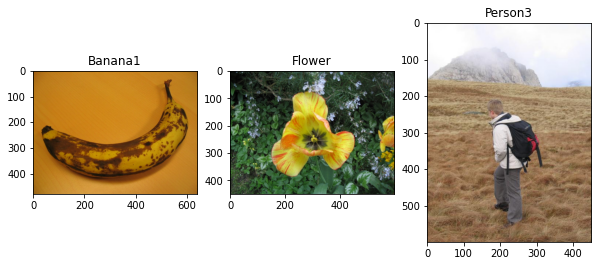

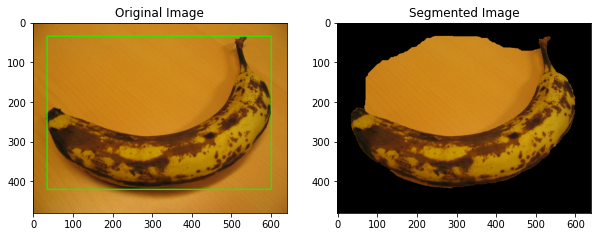

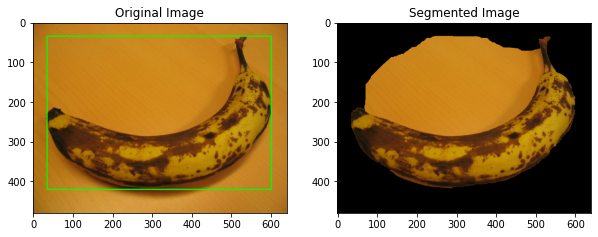

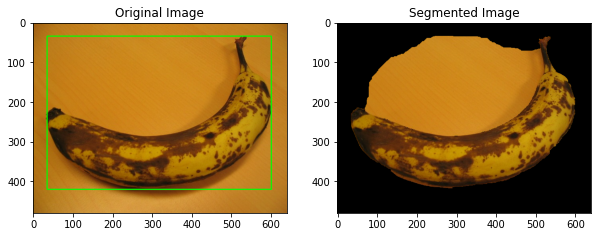

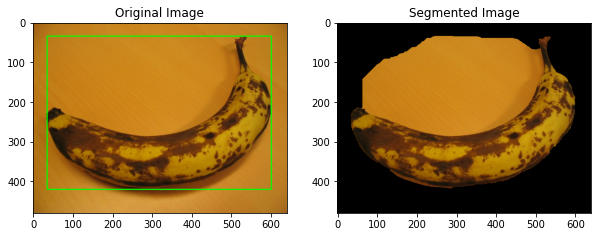

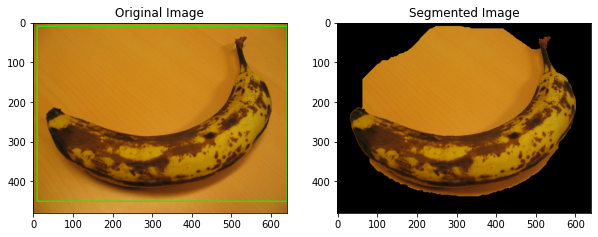

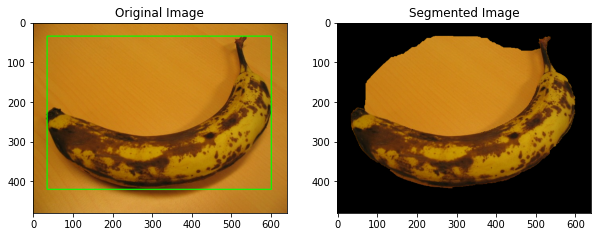

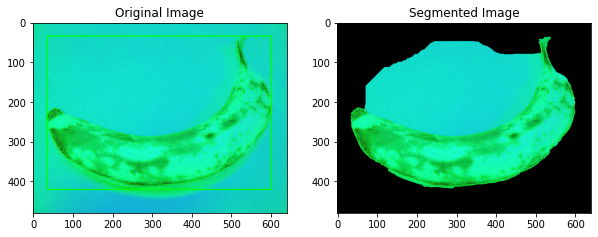

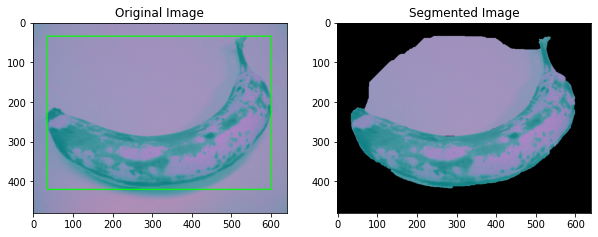

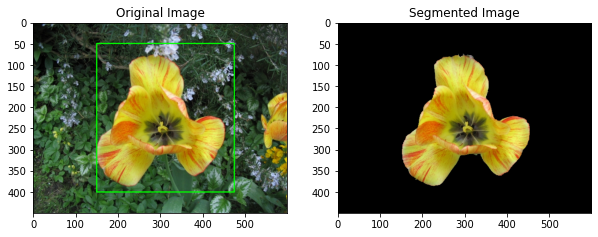

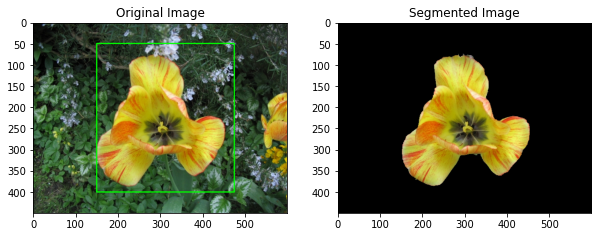

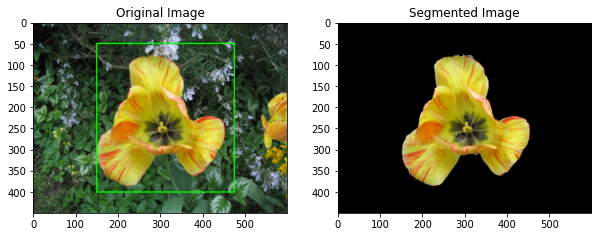

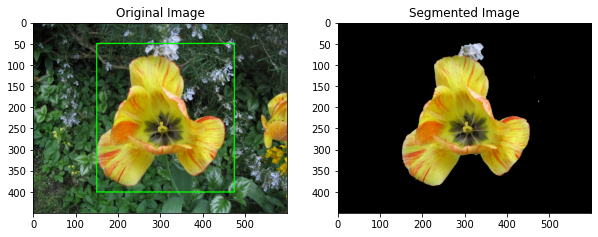

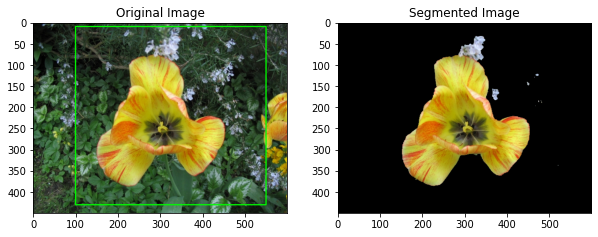

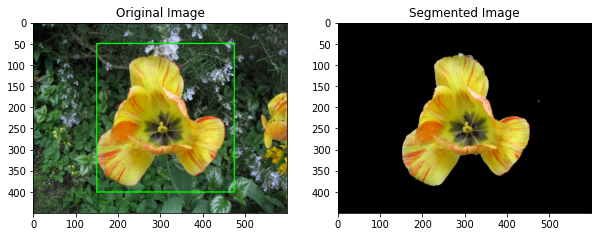

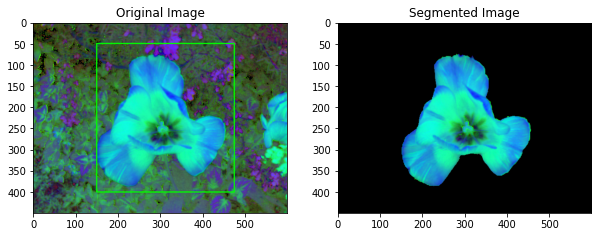

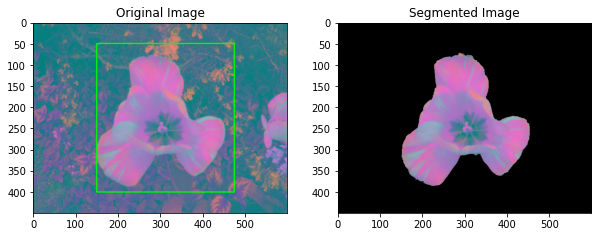

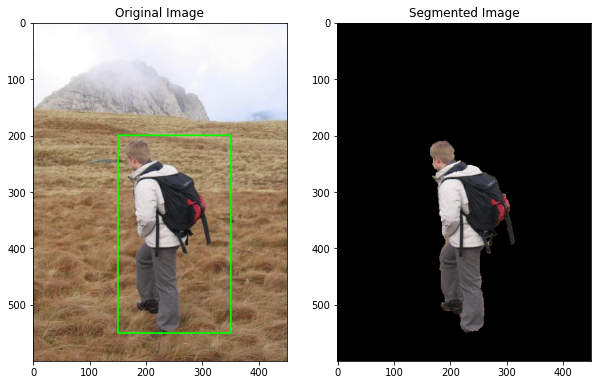

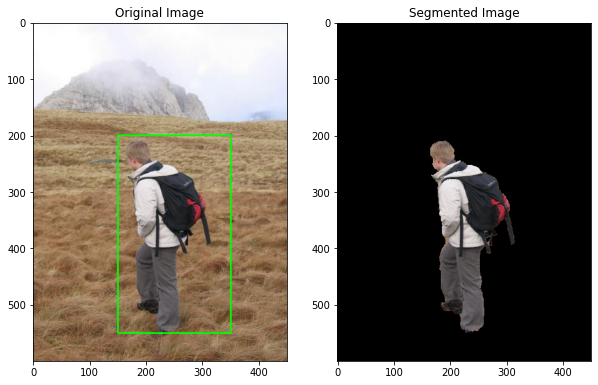

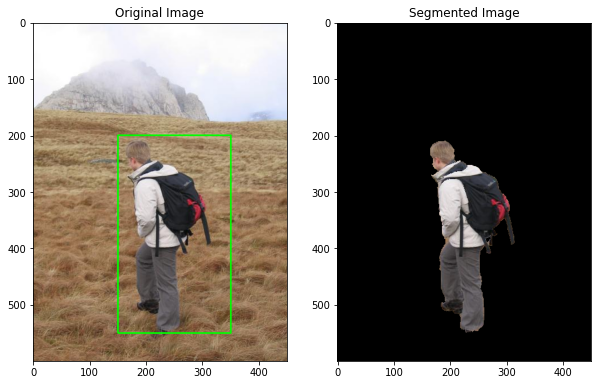

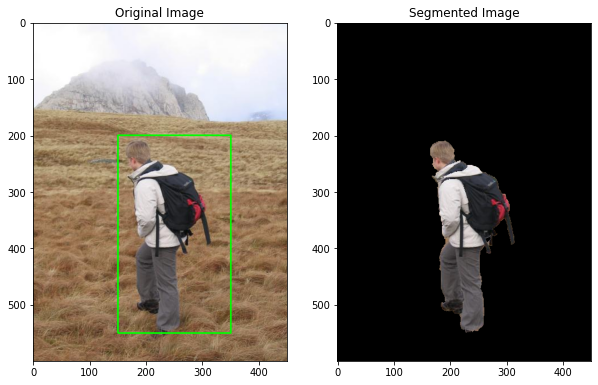

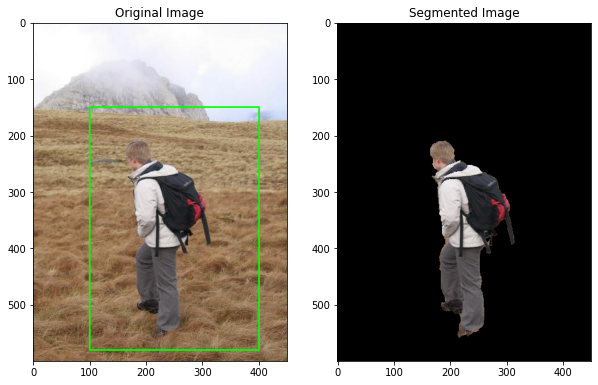

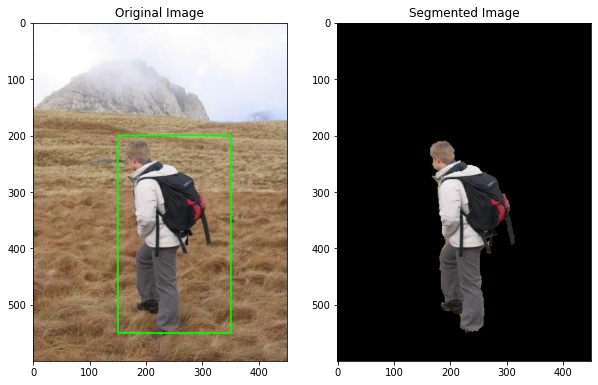

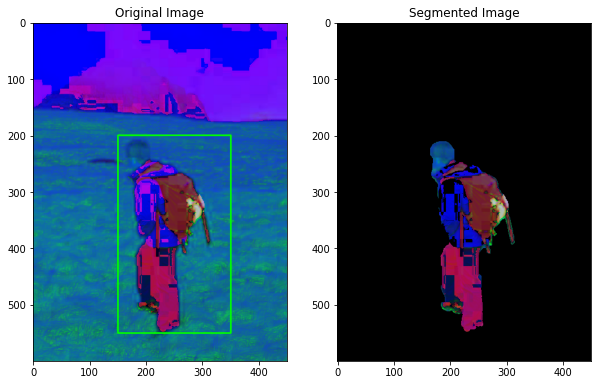

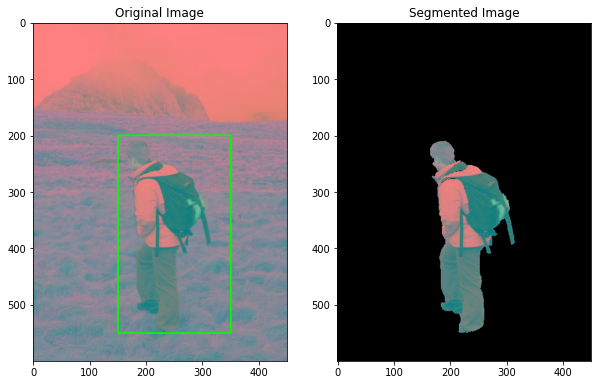

,Image,Iterations,Rectangle,Color Space,Accuracy,Jaccard,Dice
0,Banana1,5,"(35, 35, 600, 420)",RGB,0.713125,0.469335,0.638840
1,Banana1,10,"(35, 35, 600, 420)",RGB,0.715615,0.471431,0.640779
2,Banana1,20,"(35, 35, 600, 420)",RGB,0.717461,0.472961,0.642190
3,Banana1,5,"(35, 35, 600, 420)",RGB,0.704414,0.461861,0.631881
4,Banana1,5,"(10, 10, 640, 450)",RGB,0.659629,0.429334,0.600747
5,Banana1,5,"(35, 35, 600, 420)",RGB,0.715446,0.471311,0.640668
6,Banana1,5,"(35, 35, 600, 420)",HSV,0.736465,0.490628,0.658284
7,Banana1,5,"(35, 35, 600, 420)",LAB,0.716452,0.471957,0.641265
8,Flower,5,"(150, 50, 475, 400)",RGB,0.996515,0.982314,0.991078
9,Flower,10,"(150, 50, 475, 400)",RGB,0.996504,0.982259,0.991050


In [18]:
img1 = cv2.imread('../data/section-2-grabcut/images/banana1.jpg')
img2=cv2.imread('../data/section-2-grabcut/images/flower.jpg')
img3=cv2.imread('../data/section-2-grabcut/images/person3.jpg')
imgs=[img1,img2,img3]
plt.figure(figsize=(10,10))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('Banana1')
plt.subplot(132)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('Flower')
plt.subplot(133)
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title('Person3')
results=[]

iterations=[5,10,20]
color_spaces=['RGB','HSV','LAB']
rects_banana=[(35,35,600,420),(10,10,640,450)]
rects_flower=[(150,50,475,400),(100,10,550,430)]
rects_person=[(150,200,350,550),(100,150,400,580)]
rects=[rects_banana,rects_flower,rects_person]

image_names=['Banana1','Flower','Person3']
for i in range(len(imgs)):
    for j in range(len(iterations)):
        accuracy, jaccard, dice = grabcut(imgs[i],iterations[j],rects[i][0],color_spaces[0],i)
        results.append([image_names[i],iterations[j],rects[i][0],color_spaces[0],accuracy, jaccard, dice])
    
    for j in range(len(rects[i])):
        accuracy, jaccard, dice = grabcut(imgs[i],iterations[0],rects[i][j],color_spaces[0],i)
        results.append([image_names[i],iterations[0],rects[i][j],color_spaces[0],accuracy, jaccard, dice])
    
    for j in range(len(color_spaces)):
        accuracy, jaccard, dice = grabcut(imgs[i],iterations[0],rects[i][0],color_spaces[j],i)
        results.append([image_names[i],iterations[0],rects[i][0],color_spaces[j],accuracy, jaccard, dice])
    
df = pd.DataFrame(results, columns = ['Image', 'Iterations', 'Rectangle', 'Color Space', 'Accuracy', 'Jaccard', 'Dice'])
df

## Observations and Results

- **Effect of number of iterations of GMM updating and energy minimization on evaluation metrics**
  - With increase in number of iterations, the evaluation metrics improve. The grabcut algorithm updates the GMM and minimizes the energy iteratively to find the optimal segmentation. Hence, the more the number of iterations, the better the segmentation.
- **Effect of bounding box size on evaluation metrics**
  - The bounding box is used to separate the foreground from the background initially. We observe that we get better evaluaton metrics when we use a tight bounding box instead of a loose bounding box. In loose bounding box, more number of background pixels get included in the foreground which produces noise and inaccuracies for segmentation.
- **Effect of different colour spaces**
  - Different colour space can be more or less effective for segmentation depending on the image. For example in the case of banana the HSV color space gives the best results for evaluation metrics while in case of flower and person it is RGB and LAB respectively although the difference is not very significant.
- Overall we can see from the evaluation metrics that the banana image is not well segmented by the algorithm unlike the flower and person images. This is because the banana image has a lot of background pixels which are very similar to the foreground pixels in terms of colour. So the yellow pixels of the background get included in the foreground and the segmentation is not accurate.

Text(0.5, 1.0, 'Bush')

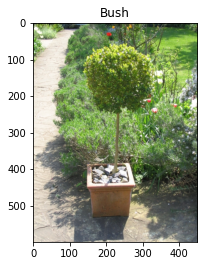

In [19]:
img4=cv2.imread('../data/section-2-grabcut/images/bush.jpg')
imgs.append(img4)
plt.figure(figsize=(10,10))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
plt.title('Bush')

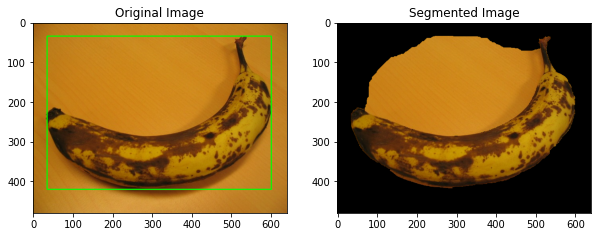

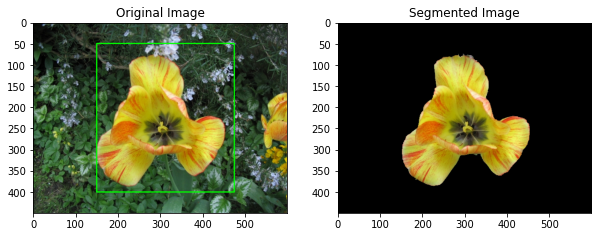

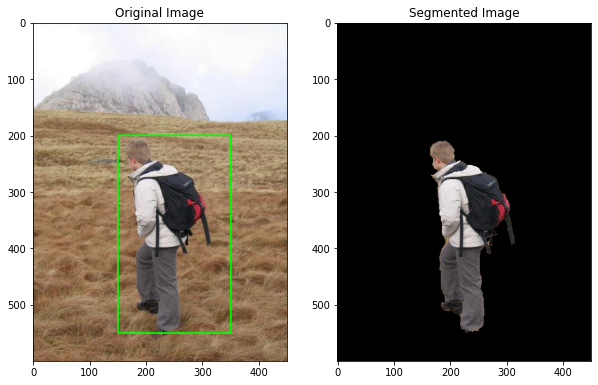

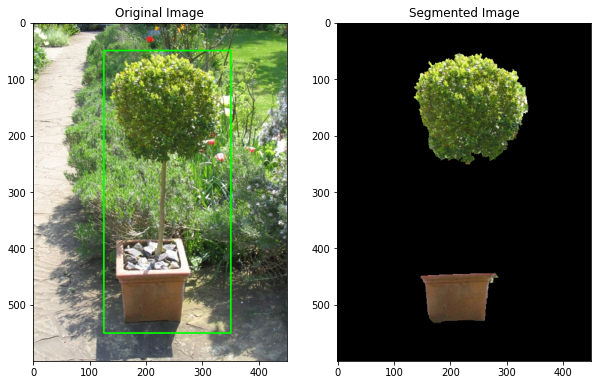

,Image,Iterations,Rectangle,Color Space,Accuracy,Jaccard,Dice
0,Banana1,10,"(35, 35, 600, 420)",RGB,0.717367,0.472980,0.642208
1,Flower,10,"(150, 50, 475, 400)",RGB,0.996511,0.982296,0.991069
2,Person3,10,"(150, 200, 350, 550)",RGB,0.995819,0.958064,0.978583
3,Bush,10,"(125, 50, 350, 550)",RGB,0.961922,0.780288,0.876586


In [20]:
rects_bush=[(125,50,350,550)]
rects.append(rects_bush)
image_names.append('Bush')

results=[]
for i in range(len(imgs)):
    accuracy, jaccard, dice = grabcut(imgs[i],iterations[1],rects[i][0],color_spaces[0],i)
    results.append([image_names[i],iterations[1],rects[i][0],color_spaces[0],accuracy, jaccard, dice])

# print the results using pandas

df = pd.DataFrame(results, columns = ['Image', 'Iterations', 'Rectangle', 'Color Space', 'Accuracy', 'Jaccard', 'Dice'])
df
    